In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import seaborn as sns
import shap

from cdc_ml.config import (
    CUSTOMER_CLASS_PROCESSED,
    FEATURE_ABLATIONS_RESULTS,
    POLLS_PROCESSED,
    PREFERENCE_PROCESSED,
    REPORTS_FIGURE,
)

from cdc_ml.features.build_features import (
    build_features,
    get_whale_users,
)

from cdc_ml.modeling.config import (
    CHOSEN_FEATURES,
    FEATS_ABL_LIST,
)

from cdc_ml.modeling.data import (
    make_holdout_split,
)

from cdc_ml.modeling.cv import(

    run_cv
)

from cdc_ml.modeling.evaluation import (
    adversarial_validation,
    compare_feature_sets,
    paired_t,
    per_customer_at_budget,
    pr_auc_ci_by_user,
)

from cdc_ml.modeling.tune import randSearch
from cdc_ml.modeling.train import train

from cdc_ml.plots import (
    bootstrapped_gain_curve,
    plot_calibration_by_volume,
)



c:\Users\zhiju\Desktop\cdc_ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-08 21:46:14.982 | INFO     | cdc_ml.config:<module>:12 - PROJ_ROOT path is: C:\Users\zhiju\Desktop\cdc_ml


In [3]:
df = pd.read_parquet(POLLS_PROCESSED)
df_pref = pd.read_parquet(PREFERENCE_PROCESSED)
df_class = pd.read_parquet(CUSTOMER_CLASS_PROCESSED)

In [4]:
df_pref.loc[(df_pref["id"]==44)]

,id,username,day_of_week,pref_start,pref_end,date,t_0830,t_1020,t_1245,t_1435,t_1625,t_1850,t_2040
1106,44,kim,4,2025-12-05 00:00:00+08:00,2025-12-05 23:00:00+08:00,2025-12-05 23:00:00+08:00,1,1,1,1,0,0,0
1107,44,kim,4,2025-12-12 00:00:00+08:00,2025-12-12 23:00:00+08:00,2025-12-12 23:00:00+08:00,1,1,1,1,0,0,0
1108,44,kim,4,2025-12-19 00:00:00+08:00,2025-12-19 23:00:00+08:00,2025-12-19 23:00:00+08:00,1,1,1,1,0,0,0
1109,44,kim,4,2025-12-26 00:00:00+08:00,2025-12-26 23:00:00+08:00,2025-12-26 23:00:00+08:00,1,1,1,1,0,0,0
1110,44,kim,0,2025-12-29 00:00:00+08:00,2025-12-30 23:00:00+08:00,2025-12-29 23:00:00+08:00,1,1,1,1,0,0,0
1111,44,kim,1,2025-12-29 00:00:00+08:00,2025-12-30 23:00:00+08:00,2025-12-30 23:00:00+08:00,1,1,1,1,0,0,0
1112,44,kim,4,2026-01-02 00:00:00+08:00,2026-01-02 23:00:00+08:00,2026-01-02 23:00:00+08:00,1,1,1,1,0,0,0
1113,44,kim,4,2026-01-09 00:00:00+08:00,2026-01-09 23:00:00+08:00,2026-01-09 23:00:00+08:00,1,1,1,1,0,0,0
1114,44,kim,4,2026-01-16 00:00:00+08:00,2026-01-16 23:00:00+08:00,2026-01-16 23:00:00+08:00,1,1,1,1,0,0,0
1115,44,kim,4,2026-01-23 00:00:00+08:00,2026-01-23 23:00:00+08:00,2026-01-23 23:00:00+08:00,1,1,1,1,0,0,0


In [5]:
df = build_features(df,df_pref,df_class)

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 29612 entries, 1126 to 29123
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype                         
---  ------                --------------  -----                         
 0   id                    29612 non-null  int64                         
 1   username              29612 non-null  str                           
 2   cycle_start           29612 non-null  datetime64[us, Asia/Singapore]
 3   cycle_end             29612 non-null  datetime64[us, Asia/Singapore]
 4   polling_at            29612 non-null  datetime64[us, Asia/Singapore]
 5   has_booking           29612 non-null  bool                          
 6   cycle_start_month     29612 non-null  int32                         
 7   cycle_start_day       29612 non-null  int32                         
 8   cycle_start_dow       29612 non-null  int32                         
 9   cycle_start_hour      29612 non-null  int32                         
 10  polling_mon

In [7]:
df.head()

,id,username,cycle_start,cycle_end,polling_at,has_booking,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,...,pref_unique_timeslot,pref_dow_count_0,pref_dow_count_1,pref_dow_count_2,pref_dow_count_3,pref_dow_count_4,pref_dow_count_5,pref_dow_count_6,date,pref_valid
1126,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-12 06:00:00+08:00,False,8,12,1,1,...,5,2,2,2,2,1,3,3,"[2025-08-18 23:00:00+08:00, 2025-08-19 23:00:0...",57
1218,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-16 02:00:00+08:00,False,8,12,1,1,...,5,2,2,2,2,1,3,3,"[2025-08-18 23:00:00+08:00, 2025-08-19 23:00:0...",57
1217,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-16 01:00:00+08:00,False,8,12,1,1,...,5,2,2,2,2,1,3,3,"[2025-08-18 23:00:00+08:00, 2025-08-19 23:00:0...",57
1216,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-16 00:00:00+08:00,False,8,12,1,1,...,5,2,2,2,2,1,3,3,"[2025-08-18 23:00:00+08:00, 2025-08-19 23:00:0...",57
1215,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-15 23:00:00+08:00,False,8,12,1,1,...,5,2,2,2,2,1,3,3,"[2025-08-18 23:00:00+08:00, 2025-08-19 23:00:0...",57


In [8]:
df["is_one_team"].describe()

count    29612.000000
mean         0.300824
std          0.458624
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: is_one_team, dtype: float64

In [9]:
df_train, df_test = make_holdout_split(df)


Train share -> 0.7927191679049034
Test share -> 0.2072808320950966
Baseline positive rate -> 0.013170336350128327
Train positive rate -> 0.013759904575274772
Test positive rate -> 0.010915607689801238


In [10]:
df_train.head(1)

,id,username,cycle_start,cycle_end,polling_at,has_booking,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,...,pref_unique_timeslot,pref_dow_count_0,pref_dow_count_1,pref_dow_count_2,pref_dow_count_3,pref_dow_count_4,pref_dow_count_5,pref_dow_count_6,date,pref_valid
1126,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-12 06:00:00+08:00,False,8,12,1,1,...,5,2,2,2,2,1,3,3,"[2025-08-18 23:00:00+08:00, 2025-08-19 23:00:0...",57


In [11]:
for test_type,test_list in FEATS_ABL_LIST.items():
    for feature_name,features_list in test_list.items():
        _ = run_cv(df_train,test_type+"_"+feature_name,features_list,m_depth=4,min_child=15,reg_lamb=15)


fold 0: train n= 18818 val n=  4656   train_pos=0.014  val_pos=0.014
  const  brier=0.0140  pr=0.0142
  marg_dow  brier=0.0140  pr=0.0153
  marg_hour brier=0.0138  pr=0.0344
  add       brier=0.0138  pr=0.0402
  joint     brier=0.0138  pr=0.0400
  rf        brier=0.0137  pr=0.0396
  xgb (val) brier=0.0138  pr=0.0403
  xgb (tr)  brier=0.0133  pr=0.0370

fold 1: train n= 19062 val n=  4412   train_pos=0.012  val_pos=0.023
  const  brier=0.0227  pr=0.0231
  marg_dow  brier=0.0227  pr=0.0301
  marg_hour brier=0.0225  pr=0.0447
  add       brier=0.0224  pr=0.0510
  joint     brier=0.0226  pr=0.0422
  rf        brier=0.0224  pr=0.0498
  xgb (val) brier=0.0224  pr=0.0511
  xgb (tr)  brier=0.0113  pr=0.0352

fold 2: train n= 18837 val n=  4637   train_pos=0.014  val_pos=0.014
  const  brier=0.0140  pr=0.0142
  marg_dow  brier=0.0140  pr=0.0181
  marg_hour brier=0.0139  pr=0.0375
  add       brier=0.0138  pr=0.0463
  joint     brier=0.0139  pr=0.0378
  rf        brier=0.0139  pr=0.0365
  xgb (v

In [12]:
xgb_records = pd.read_json(FEATURE_ABLATIONS_RESULTS,lines=True)
model_metrics = compare_feature_sets(target_run="full_loo_loo")

In [13]:
model_metrics

,run_at,run_id,feature_id,split,group,n_folds,seed,features,n,base_rate,...,imp_pref_dow_count_4,imp_pref_coverage,imp_pref_dow_count_3,imp_is_one_team,imp_pref_dow_count_0,imp_pref_dow_count_6,imp_pref_unique_day,imp_pref_dow_count_1,imp_pref_dow_count_2,imp_pref_dow_count_5


In [14]:
X_train, y_train = df_train[CHOSEN_FEATURES],df_train["has_booking"].to_numpy()

X_test, y_test = df_test[CHOSEN_FEATURES], df_test["has_booking"].to_numpy()

In [15]:
randSearch(X_train,y_train,df_train["username"])

Fitting 5 folds for each of 50 candidates, totalling 250 fits
0.07289146930776999 {'subsample': 0.7, 'reg_lambda': 5, 'n_estimators': 400, 'min_child_weight': 20, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 1.0}
2026-06-08 21:48:04.123 | SUCCESS  | cdc_ml.modeling.tune:randSearch:28 - Saved best params to C:\Users\zhiju\Desktop\cdc_ml\models\best_params.json


In [16]:
model,oof_cal = train(df_train)

2026-06-08 21:48:04.807 | SUCCESS  | cdc_ml.modeling.train:train:64 - Saved model to C:\Users\zhiju\Desktop\cdc_ml\models\booking_model_v1.joblib


In [17]:
whales_pc,_ = get_whale_users()
whales_pt_mask_train = df_train["username"].isin(whales_pc).to_numpy()
non_whales_pt_mask_train = ~df_train["username"].isin(whales_pc).to_numpy()

whales_pt_mask_test = df_test["username"].isin(whales_pc).to_numpy()
non_whales_pt_mask_test = ~df_test["username"].isin(whales_pc).to_numpy()

In [18]:
p_cal = model.predict_proba(df_test)

whale_users = df_test.loc[whales_pt_mask_test,["username"]]
non_whales_users = df_test.loc[non_whales_pt_mask_test,["username"]]
print("ALL");        pr_auc_ci_by_user(y_test, p_cal, df_test["username"])
print("WHALES");     pr_auc_ci_by_user(y_test[whales_pt_mask_test],  p_cal[whales_pt_mask_test],  whale_users)
print("NON-WHALES"); pr_auc_ci_by_user(y_test[~whales_pt_mask_test], p_cal[~whales_pt_mask_test], non_whales_users)

ALL
users=7 rows=6138 positives=67 base=0.0109
PR-AUC=0.0252 (2.31x)  95% CI=[0.0139, 0.0482] ([1.28x, 4.42x])

WHALES
users=1 rows=3816 positives=22 base=0.0058
PR-AUC=0.0112 (1.94x)  95% CI=[0.0112, 0.0112] ([1.94x, 1.94x])

NON-WHALES
users=6 rows=2322 positives=45 base=0.0194
PR-AUC=0.0313 (1.62x)  95% CI=[0.0201, 0.0571] ([1.03x, 2.95x])



([0.05707265642349774,
  0.038693702789262915,
  0.05864319144566134,
  0.03472388428489983,
  0.02958894197924865,
  0.04352016855459208,
  0.022470295831438475,
  0.04784739465887538,
  0.027322908822491002,
  0.02890393391880532,
  0.022844381790077143,
  0.03943725300494999,
  0.02145834041183816,
  0.041103620674572884,
  0.03293149691975023,
  0.04023663735810083,
  0.022240967241887028,
  0.027976897484063436,
  0.027849098204466176,
  0.025761838049973198,
  0.033873322000649894,
  0.04662852474013271,
  0.022228263589789903,
  0.05281071619699486,
  0.02077396342663441,
  0.029352190171959072,
  0.0308856713876837,
  0.02565670106637058,
  0.022517553550026888,
  0.02821641722876321,
  0.03004311592857494,
  0.029787756209971275,
  0.029352190171959072,
  0.019624151895585275,
  0.02734479408323772,
  0.0370166503369303,
  0.033442442021164705,
  0.038693702789262915,
  0.03747777733892957,
  0.03526135293600187,
  0.028947362422987663,
  0.041739053335350815,
  0.033893780237

In [19]:
clf = adversarial_validation(X_train[CHOSEN_FEATURES], X_test[CHOSEN_FEATURES])

adversarial AUC = 0.798   (0.5 = identical, ~0.65+ = medium, 0.8+ = strong)


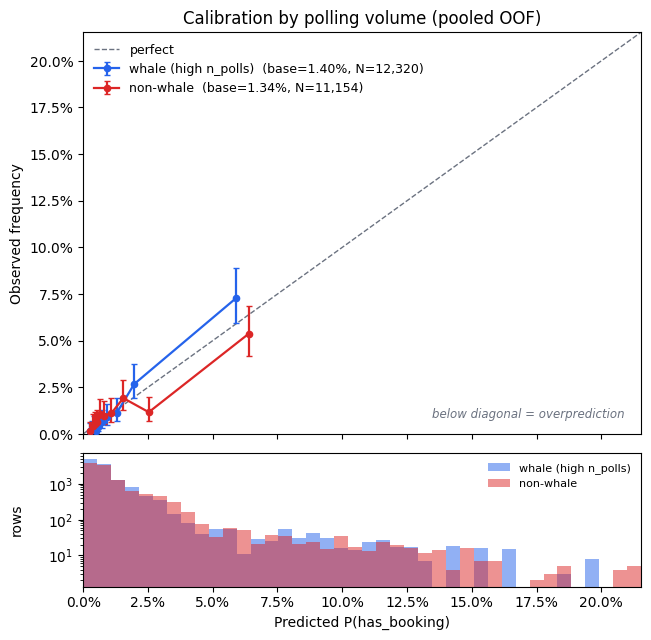

In [20]:
fig = plot_calibration_by_volume(oof_cal,y_train,whales_pt_mask_train);
fig.savefig(REPORTS_FIGURE/"oof_cali.png")

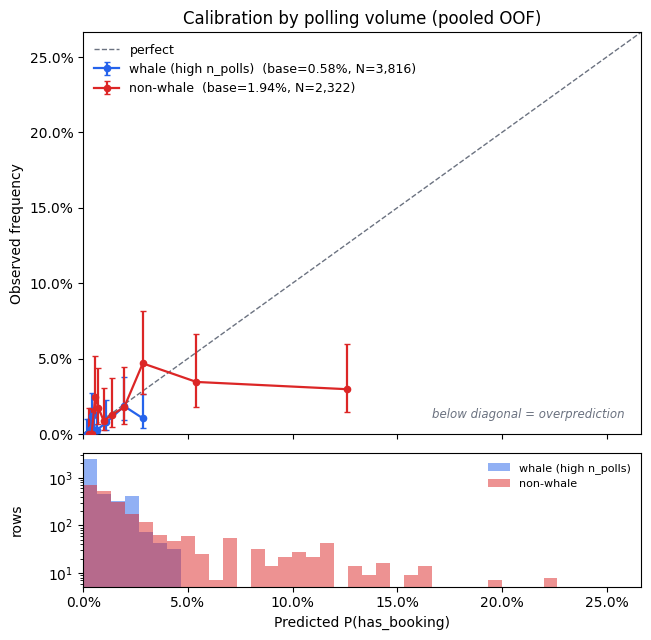

In [21]:
fig = plot_calibration_by_volume(
    p_cal,
    y_test,
    whales_pt_mask_test
)

fig.savefig(REPORTS_FIGURE/"test_cali.png")

 booking whales: median recall 80%, worst 64%  (n=2)
       the rest: median recall 100%, worst 57%  (n=5)


<Axes: xlabel='whale', ylabel='recall'>

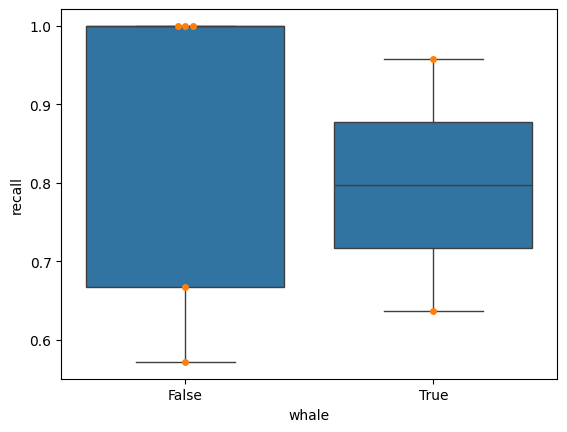

In [22]:
t = per_customer_at_budget(df_test, p_cal, budget=0.50)
for name, g in [("booking whales", t[t.whale]), ("the rest", t[~t.whale])]:
    print(f"{name:>15}: median recall {g.recall.median():.0%}, "
          f"worst {g.recall.min():.0%}  (n={len(g)})")
sns.boxplot(data=t,x="whale",y="recall")  # if you want the distribution, not just the summary
sns.swarmplot(data=t,x="whale",y="recall")  # if you want the distribution, not just the summary

 booking whales: median recall 88%, worst 48%  (n=4)
       the rest: median recall 85%, worst 0%  (n=26)


<Axes: xlabel='whale', ylabel='recall'>

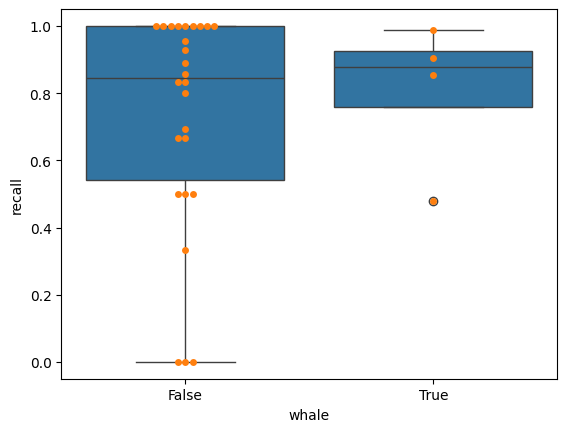

In [23]:

t = per_customer_at_budget(df_train, oof_cal, budget=0.50)
for name, g in [("booking whales", t[t.whale]), ("the rest", t[~t.whale])]:
    print(f"{name:>15}: median recall {g.recall.median():.0%}, "
          f"worst {g.recall.min():.0%}  (n={len(g)})")
sns.boxplot(data=t,x="whale",y="recall")  # if you want the distribution, not just the summary
sns.swarmplot(data=t,x="whale",y="recall")  # if you want the distribution, not just the summary

In [25]:
# fig, res = bootstrapped_gain_curve(df_train, oof_cal)
# fig.savefig(REPORTS_FIGURE/"bootstrapped_gain_curve_oof.png")
# print(f"90% of bookings for {res['budget']*100:.0f}% of polls (95% CI {res['budget_ci'][0]*100:.0f}-{res['budget_ci'][2]*100:.0f}%)")

In [26]:
# fig, res = bootstrapped_gain_curve(df_test, p_cal)
# fig.savefig(REPORTS_FIGURE/"bootstrapped_gain_curve_test.png")
# print(f"90% of bookings for {res['budget']*100:.0f}% of polls (95% CI {res['budget_ci'][0]*100:.0f}-{res['budget_ci'][2]*100:.0f}%)")

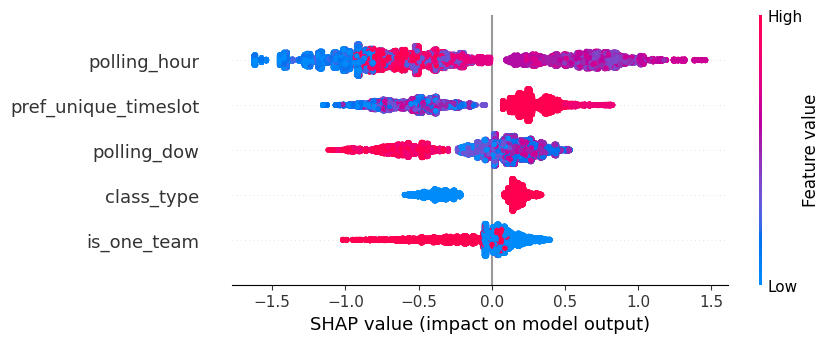

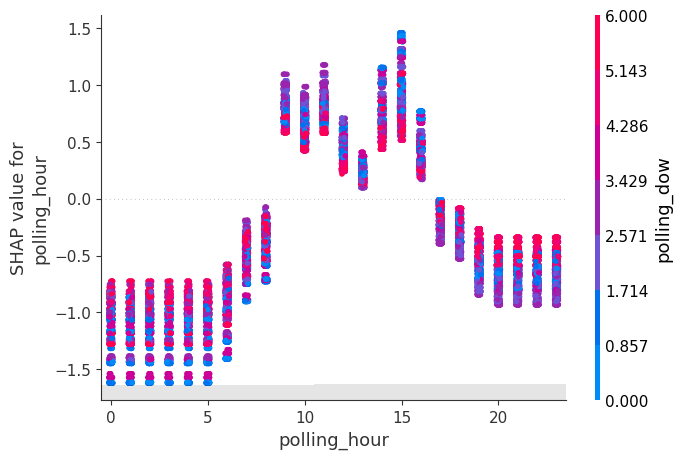

In [27]:
explainer = shap.TreeExplainer(model.booster)   # raw margin = log-odds
sv = explainer(df_train[CHOSEN_FEATURES])                   # X_eval = held-out sample
shap.plots.beeswarm(sv)
shap.plots.scatter(sv[:, "polling_hour"], color=sv[:, "polling_dow"])
# older shap: shap.summary_plot(explainer.shap_values(X_eval), X_eval)